# 고객 행동 분석

`customer_behavior_analysis.py`의 분석 흐름을 주피터 노트북으로 옮긴 파일입니다.

확인할 내용:

- 고객별 총소비금액, 평균소비금액, 거래횟수
- 고객별 사기거래횟수와 사기비율
- 상위 소비 고객 TOP 10
- 거래횟수와 평균소비금액의 관계
- 시간대별 평균 소비금액
- 사기 거래와 정상 거래의 평균 금액 차이

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from matplotlib import font_manager

In [2]:
# 한글 폰트 설정
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

display(HTML("""
<style>
.jp-Notebook { font-size: 13px; }
.jp-RenderedMarkdown { font-size: 13px; line-height: 1.55; }
.jp-RenderedMarkdown h1 { font-size: 22px; }
.jp-RenderedMarkdown h2 { font-size: 17px; }
.jp-RenderedMarkdown h3 { font-size: 15px; }
.jp-OutputArea-output, .jp-RenderedText, .jp-OutputArea pre { font-size: 12px; }
.dataframe { font-size: 11px; }
</style>
"""))

## 1. 데이터 로드

원본 파이썬 파일은 `data/credit_card_transactions.csv`를 읽습니다. 노트북에서는 현재 프로젝트 상태에 맞게 `data/`가 없으면 `step1/data/`를 자동으로 사용합니다.

In [3]:
def get_data_path():
    current_dir = Path.cwd()
    candidates = [
        current_dir / "data" / "credit_card_transactions.csv",
        current_dir / "step1" / "data" / "credit_card_transactions.csv",
        current_dir.parent / "data" / "credit_card_transactions.csv",
        current_dir.parent / "step1" / "data" / "credit_card_transactions.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "credit_card_transactions.csv 파일을 찾을 수 없습니다. "
        "data/ 또는 step1/data/ 폴더를 확인하세요."
    )


data_path = get_data_path()
print(f"[데이터 파일] {data_path}")

df = pd.read_csv(data_path)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

required_columns = {"cc_num", "amt", "is_fraud", "trans_date_trans_time"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"필수 컬럼이 없습니다: {sorted(missing_columns)}")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day_name()

print(df.shape)
df.head()

[데이터 파일] /Users/sungjh/Projects/hana_power_on/step1/data/credit_card_transactions.csv
(1296675, 25)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,hour,day
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,0,Tuesday
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,0,Tuesday
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,0,Tuesday
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,0,Tuesday
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,0,Tuesday


## 2. 고객 단위 행동 분석

`cc_num` 기준으로 고객을 묶고, 총소비금액, 평균소비금액, 거래횟수, 사기거래횟수, 사기비율을 계산합니다.

In [4]:
customer_group = df.groupby("cc_num")

customer_behavior = customer_group.agg(
    총소비금액=("amt", "sum"),
    평균소비금액=("amt", "mean"),
    거래횟수=("amt", "count"),
    사기거래횟수=("is_fraud", "sum"),
)

customer_behavior["사기비율"] = (
    customer_behavior["사기거래횟수"] / customer_behavior["거래횟수"]
)

customer_behavior.head()

,총소비금액,평균소비금액,거래횟수,사기거래횟수,사기비율
cc_num,,,,,
60416207185,85043.47,56.023366,1518,9,0.005929
60422928733,105640.20,69.000784,1531,12,0.007838
60423098130,58673.63,115.046333,510,10,0.019608
60427851591,59129.61,111.987898,528,14,0.026515
60487002085,25160.11,50.726028,496,0,0.000000


## 3. 상위 소비 고객 TOP 10

총소비금액이 큰 고객 10명을 확인합니다.

In [5]:
top_spenders = customer_behavior.sort_values("총소비금액", ascending=False).head(10)
top_spenders

,총소비금액,평균소비금액,거래횟수,사기거래횟수,사기비율
cc_num,,,,,
6011367958204270,296436.73,95.317277,3110,0,0.000000
4908846471916297,290478.49,95.583577,3039,3,0.000987
6011438889172900,284013.50,91.440277,3106,14,0.004507
36722699017270,280008.05,89.774944,3119,7,0.002244
6011893664860915,278325.97,90.073129,3090,0,0.000000
6011109736646996,278139.27,89.693412,3101,2,0.000645
3583635130604947,278042.99,91.884663,3026,0,0.000000
2712209726293386,277085.65,90.432653,3064,0,0.000000
4836998673805450,275930.63,91.156468,3027,4,0.001321


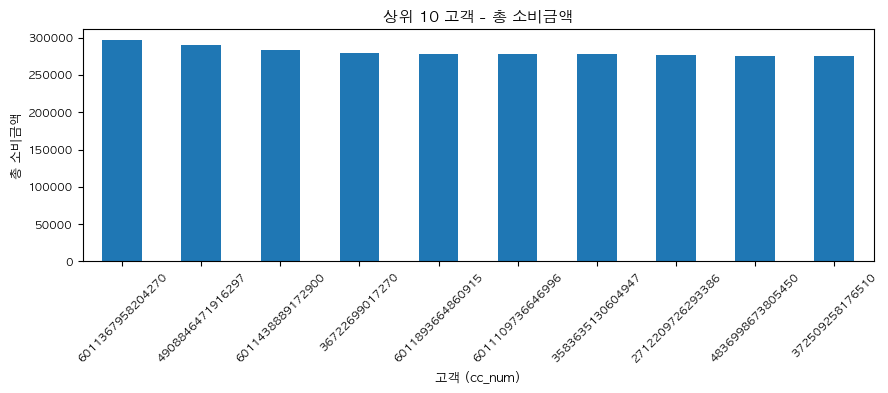

In [6]:
plt.figure(figsize=(9, 4))
top_spenders["총소비금액"].plot(kind="bar")
plt.title("상위 10 고객 - 총 소비금액")
plt.xlabel("고객 (cc_num)")
plt.ylabel("총 소비금액")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 거래 횟수 vs 평균 소비금액

거래를 많이 하는 고객과 한 번에 큰 금액을 쓰는 고객을 구분해서 볼 수 있습니다.

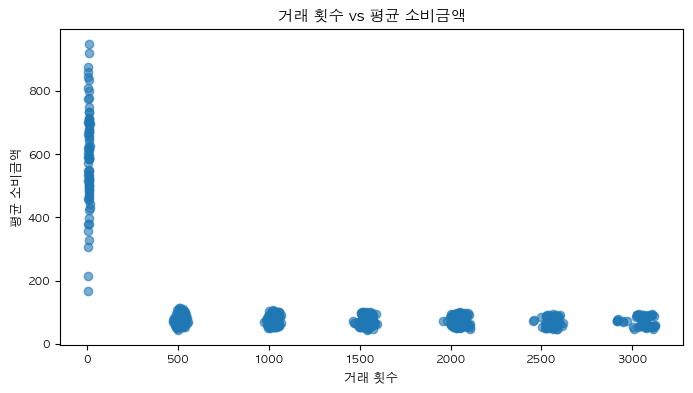

In [7]:
plt.figure(figsize=(7, 4))
plt.scatter(
    customer_behavior["거래횟수"],
    customer_behavior["평균소비금액"],
    alpha=0.6,
)
plt.title("거래 횟수 vs 평균 소비금액")
plt.xlabel("거래 횟수")
plt.ylabel("평균 소비금액")
plt.tight_layout()
plt.show()

## 5. 시간대별 평균 소비금액

거래 발생 시간에서 `hour`를 추출해 시간대별 평균 결제 금액을 확인합니다.

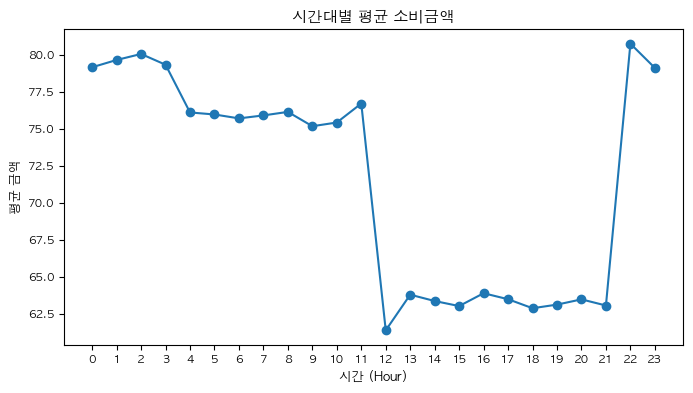

In [8]:
hourly_spend = df.groupby("hour")["amt"].mean()

plt.figure(figsize=(7, 4))
hourly_spend.plot(kind="line", marker="o")
plt.title("시간대별 평균 소비금액")
plt.xlabel("시간 (Hour)")
plt.ylabel("평균 금액")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 6. 사기 vs 정상 거래 평균 금액 비교

`is_fraud` 값이 0인 정상 거래와 1인 사기 거래의 평균 결제 금액을 비교합니다.

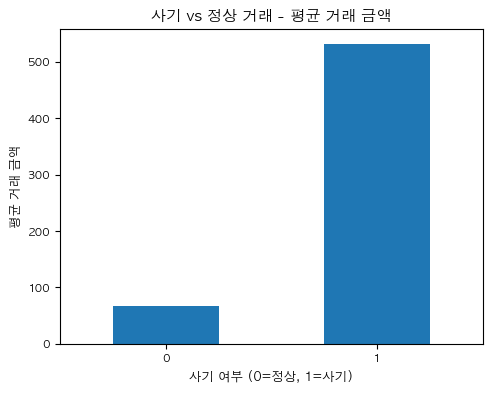

In [9]:
fraud_group = df.groupby("is_fraud")["amt"].mean()

plt.figure(figsize=(5, 4))
fraud_group.plot(kind="bar")
plt.title("사기 vs 정상 거래 - 평균 거래 금액")
plt.xlabel("사기 여부 (0=정상, 1=사기)")
plt.ylabel("평균 거래 금액")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. 결과 해석

- `총소비금액`이 큰 고객은 전체 소비 규모가 큰 고객입니다.
- `평균소비금액`이 큰 고객은 1회 결제 금액이 큰 고객입니다.
- `거래횟수`가 큰 고객은 활동성이 높은 고객입니다.
- `사기비율`이 높은 고객은 위험 계정 후보로 볼 수 있습니다.
- 시간대별 평균 소비금액이 특정 시간에 튀면 이상 거래 탐지 feature로 활용할 수 있습니다.